In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('telo_cleaned.csv')
display(df.head())

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Yes,No,1,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,0,No,No,34,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,0,No,No,2,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,0,No,No,45,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,0,No,No,2,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
cat_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Khích thước dữ liệu sau mã hóa:", df_encoded.shape)
display(df_encoded.head())

Khích thước dữ liệu sau mã hóa: (7032, 29)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Partner_Yes,Dependents_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,True,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,False,True,...,False,False,False,False,False,False,True,False,True,False


In [3]:
X = df_encoded.drop("Churn", axis = 1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=42, stratify=y)
print(f"số lượng mẫu train:{X_train.shape[0]}")
print(f"Số lượng mẫu test {X_test.shape[0]}")

số lượng mẫu train:5625
Số lượng mẫu test 1407


Chuẩn hóa dữ liệu 

In [4]:
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])



xử lý mất cân bằng dữ liệu (SMOTE)

Chọn điểm A trong bộ Churn = 1

chọn ngẫu nhiên 1 trong k điểm gần nhất gọi là B, sau 

Tạo ra điểm mới là C ở giữa A và B

$$
C = A + \lambda \times (B - A)
$$

In [5]:
def manual_smote(X_minority, num_synthetic_samples, k=5):
    # Thêm dòng này ở đầu hàm manual_smote
    X_minority = np.array(X_minority, dtype=np.float64)
    n_samples, n_features = X_minority.shape
    synthetic_data = []

    for _ in range(num_synthetic_samples):
        idx_A = np.random.randint(0, n_samples)
        A = X_minority[idx_A]

        distances = np.linalg.norm(X_minority-A, axis = 1)
        nearest_indices = np.argsort(distances)[1:k+1]

        idx_B = np.random.choice(nearest_indices)
        B = X_minority[idx_B]

        lambd = np.random.rand()
        C = A + lambd*(B-A)

        synthetic_data.append(C)

    return np.array(synthetic_data)


In [6]:
X_train_np = X_train.values
y_train_np = y_train.values

X_majority = X_train_np[y_train_np ==0]
X_minority = X_train_np[y_train_np ==1]

num_to_gen = len(X_majority) - len(X_minority)
X_synthetic = manual_smote(X_minority, num_to_gen, k=5)
y_synthetic = np.ones(num_to_gen)
X_train_resampled_np = np.vstack((X_majority,X_minority,X_synthetic))
y_train_resampled_np = np.hstack((np.zeros(len(X_majority)), np.ones(len(X_minority)), y_synthetic))

X_train_resampled = pd.DataFrame(X_train_resampled_np, columns=X_train.columns)
y_train_resampled = pd.Series(y_train_resampled_np, name='Churn')

print("Số lượng mẫu sau khi dùng SMOTE:", y_train_resampled.value_counts())

Số lượng mẫu sau khi dùng SMOTE: Churn
0.0    4130
1.0    4130
Name: count, dtype: int64


In [7]:
display(X_train_resampled.head())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Partner_Yes,Dependents_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1.321816,0.981556,1.6599,True,True,False,True,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,-0.26741,-0.971546,-0.562252,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0,1.444064,0.837066,1.756104,True,False,False,True,True,False,...,False,False,False,False,False,True,False,True,False,False
3,0,-1.204646,0.641092,-0.908326,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,True,False
4,0,0.669826,-0.808787,-0.101561,True,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [8]:
actual_model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [] 
}

def save_model_results(model_results,model_name, y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (TP + TN) / len(y_true)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    model_results['Mô hình'].append(model_name)
    model_results['Accuracy'].append(accuracy)
    model_results['Precision'].append(precision)
    model_results['Recall'].append(recall)
    model_results['F1-Score'].append(f1_score)

    print(f"Đã lưu kết quả cho {model_name}")



In [9]:
from CustomLogisticRegression import CustomLogisticRegression

In [22]:
def create_comparison_table(model_results): 
    # Ép dictionary chứa dữ liệu THẬT thành DataFrame
    df_compare_actual = pd.DataFrame(model_results)

    # 1. In ra bảng tô màu nhiệt
    print("BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:")
    display(df_compare_actual.style.background_gradient(cmap='Greens', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score']) \
                               .format("{:.4f}", subset=['Accuracy', 'Precision', 'Recall', 'F1-Score']))

    # 2. Vẽ biểu đồ (y hệt code cũ, chỉ đổi tên df)
    df_melted = df_compare_actual.melt(id_vars='Mô hình', var_name='Chỉ số', value_name='Điểm số')

    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    ax = sns.barplot(x='Mô hình', y='Điểm số', hue='Chỉ số', data=df_melted, palette='viridis')

    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.3f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), textcoords = 'offset points', fontsize=10)

    plt.title('So sánh Hiệu suất Thực tế giữa các Mô hình', fontsize=16, fontweight='bold')
    plt.ylim(0, 1.1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

Đã lưu kết quả cho Ridge (lambda=0.01)
Đã lưu kết quả cho Ridge (lambda=0.1)
Đã lưu kết quả cho Ridge (lambda=1.0)
Đã lưu kết quả cho Ridge (lambda=10.0)
Đã lưu kết quả cho Ridge (lambda=100.0)
Đã lưu kết quả cho Ridge (lambda=1000.0)
Đã lưu kết quả cho Ridge (lambda=10000.0)
Đã lưu kết quả cho Ridge (lambda=100000.0)
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,Ridge (lambda=0.01),0.7321,0.4974,0.7781,0.6069
1,Ridge (lambda=0.1),0.7321,0.4974,0.7781,0.6069
2,Ridge (lambda=1.0),0.7321,0.4974,0.7781,0.6069
3,Ridge (lambda=10.0),0.7321,0.4974,0.7781,0.6069
4,Ridge (lambda=100.0),0.7321,0.4974,0.7807,0.6077
5,Ridge (lambda=1000.0),0.7321,0.4975,0.7914,0.6109
6,Ridge (lambda=10000.0),0.7285,0.4934,0.7941,0.6086
7,Ridge (lambda=100000.0),0.7264,0.4908,0.7834,0.6035


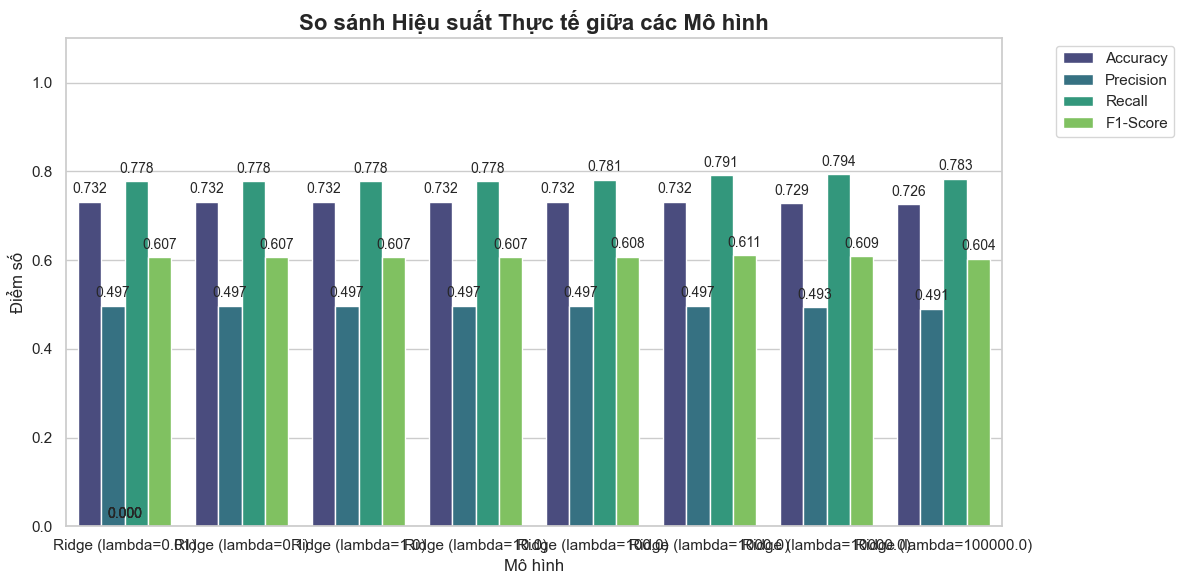

In [23]:
model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [] 
}

lambda_value = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0,10000.0, 100000.0]
for lam in lambda_value:
    model_ridge = CustomLogisticRegression(learning_rate=0.01, num_iterations=2000, penalty='l2', lambda_param=lam)
    model_ridge.fit(X_train_resampled_np.astype(float), y_train_resampled_np.astype(float))
    y_pred_ridge = model_ridge.predict(X_test.values.astype(float))
    save_model_results(model_results, f'Ridge (lambda={lam})', y_test.values, y_pred_ridge)
create_comparison_table(model_results)

Đã lưu kết quả cho Lasso (lambda=0.01)
Đã lưu kết quả cho Lasso (lambda=0.1)
Đã lưu kết quả cho Lasso (lambda=1.0)
Đã lưu kết quả cho Lasso (lambda=10.0)
Đã lưu kết quả cho Lasso (lambda=100.0)
Đã lưu kết quả cho Lasso (lambda=1000.0)
Đã lưu kết quả cho Lasso (lambda=10000.0)
Đã lưu kết quả cho Lasso (lambda=100000.0)
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,Lasso (lambda=0.01),0.7321,0.4974,0.7781,0.6069
1,Lasso (lambda=0.1),0.7321,0.4974,0.7781,0.6069
2,Lasso (lambda=1.0),0.7321,0.4974,0.7781,0.6069
3,Lasso (lambda=10.0),0.7328,0.4983,0.7781,0.6075
4,Lasso (lambda=100.0),0.7363,0.5026,0.7888,0.6139
5,Lasso (lambda=1000.0),0.6368,0.4028,0.7594,0.5264
6,Lasso (lambda=10000.0),0.6340,0.4090,0.8476,0.5518
7,Lasso (lambda=100000.0),0.5281,0.1580,0.1791,0.1679


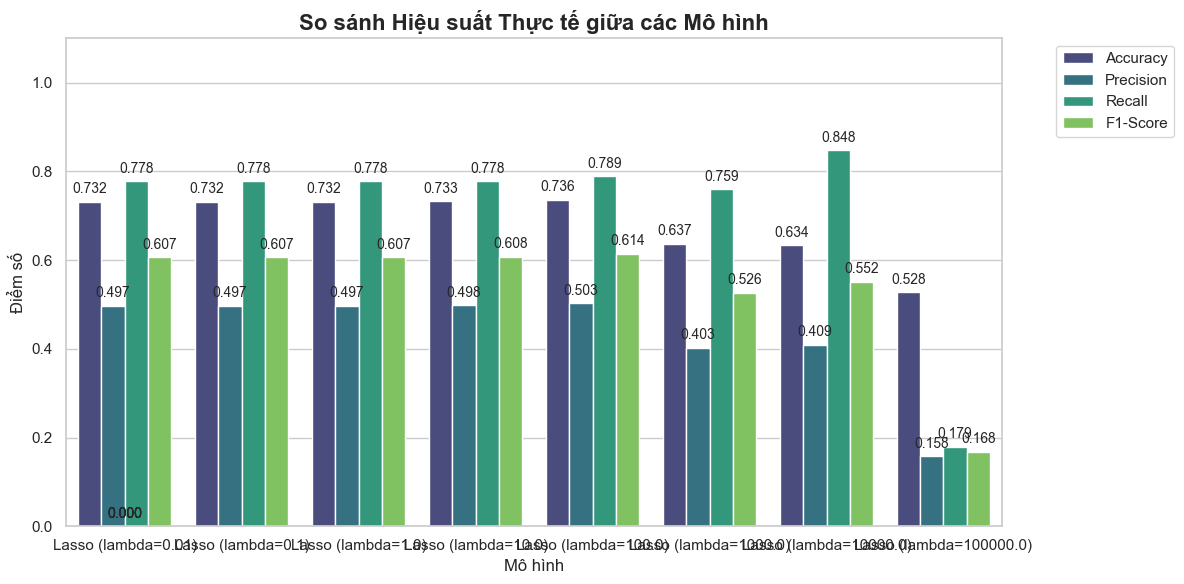

In [24]:
model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [] 
}

lambda_value = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0,10000.0, 100000.0]
for lam in lambda_value:
    model_lasso = CustomLogisticRegression(learning_rate=0.01, num_iterations=2000, penalty='l1', lambda_param=lam)
    model_lasso.fit(X_train_resampled_np.astype(float), y_train_resampled_np.astype(float))
    y_pred_lasso = model_lasso.predict(X_test.values.astype(float))
    save_model_results(model_results, f'Lasso (lambda={lam})', y_test.values, y_pred_lasso)
create_comparison_table(model_results)

In [27]:


model_standard = CustomLogisticRegression(learning_rate = 0.01, num_iterations = 2000, penalty = 'none')
model_ridge = CustomLogisticRegression(learning_rate=0.01, num_iterations=2000, penalty='l2', lambda_param=1000.0)
model_lasso = CustomLogisticRegression(learning_rate=0.01, num_iterations=2000, penalty='l1', lambda_param=100.0)



Đã lưu kết quả cho Logistic Regression Chuẩn
Đã lưu kết quả cho Logistic Regression Ridge
Đã lưu kết quả cho Logistic Regression Lasso
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression Chuẩn,0.7321,0.4974,0.7781,0.6069
1,Logistic Regression Ridge,0.7321,0.4975,0.7914,0.6109
2,Logistic Regression Lasso,0.7363,0.5026,0.7888,0.6139


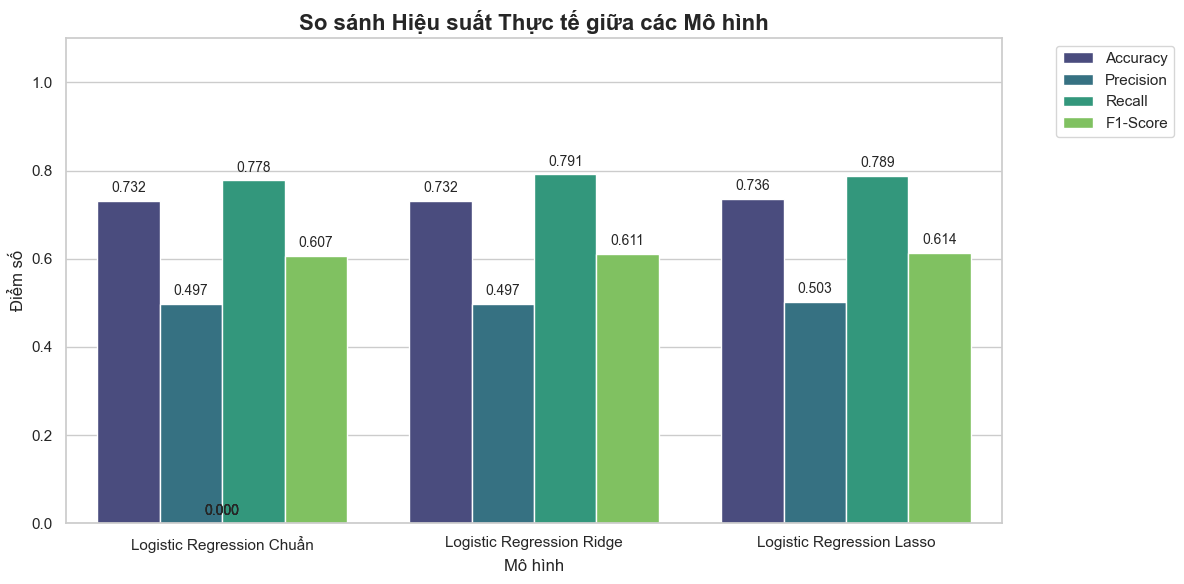

In [65]:
LR_model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [] 
}


model_standard.fit(X_train_resampled.values.astype(float), y_train_resampled.values.astype(float))
y_pred_standard = model_standard.predict(X_test.values.astype(float))
save_model_results(LR_model_results,"Logistic Regression Chuẩn", y_test.values, y_pred_standard)

model_ridge.fit(X_train_resampled.values.astype(float), y_train_resampled.values.astype(float))
y_pred_ridge = model_ridge.predict(X_test.values.astype(float))
save_model_results(LR_model_results,"Logistic Regression Ridge", y_test.values, y_pred_ridge)

model_lasso.fit(X_train_resampled.values.astype(float), y_train_resampled.values.astype(float))
y_pred_lasso = model_lasso.predict(X_test.values.astype(float))
save_model_results(LR_model_results,"Logistic Regression Lasso", y_test.values, y_pred_lasso)

create_comparison_table(LR_model_results)

In [29]:
from KNN import CustomKNN

Đã lưu kết quả cho KNN (k=1) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=2) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=3) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=4) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=5) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=6) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=7) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=8) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=9) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=10) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=11) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=12) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=13) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=14) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=15) (p=2) (uniform)
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,KNN (k=1) (p=2) (uniform),0.7221,0.4809,0.5722,0.5226
1,KNN (k=2) (p=2) (uniform),0.7441,0.5205,0.4759,0.4972
2,KNN (k=3) (p=2) (uniform),0.7001,0.4568,0.6791,0.5462
3,KNN (k=4) (p=2) (uniform),0.7257,0.4872,0.6123,0.5427
4,KNN (k=5) (p=2) (uniform),0.6866,0.4439,0.7086,0.5458
5,KNN (k=6) (p=2) (uniform),0.7136,0.4726,0.6684,0.5537
6,KNN (k=7) (p=2) (uniform),0.6887,0.4481,0.7380,0.5576
7,KNN (k=8) (p=2) (uniform),0.7093,0.4692,0.7139,0.5663
8,KNN (k=9) (p=2) (uniform),0.6859,0.4465,0.7594,0.5624
9,KNN (k=10) (p=2) (uniform),0.7072,0.4675,0.7299,0.5699


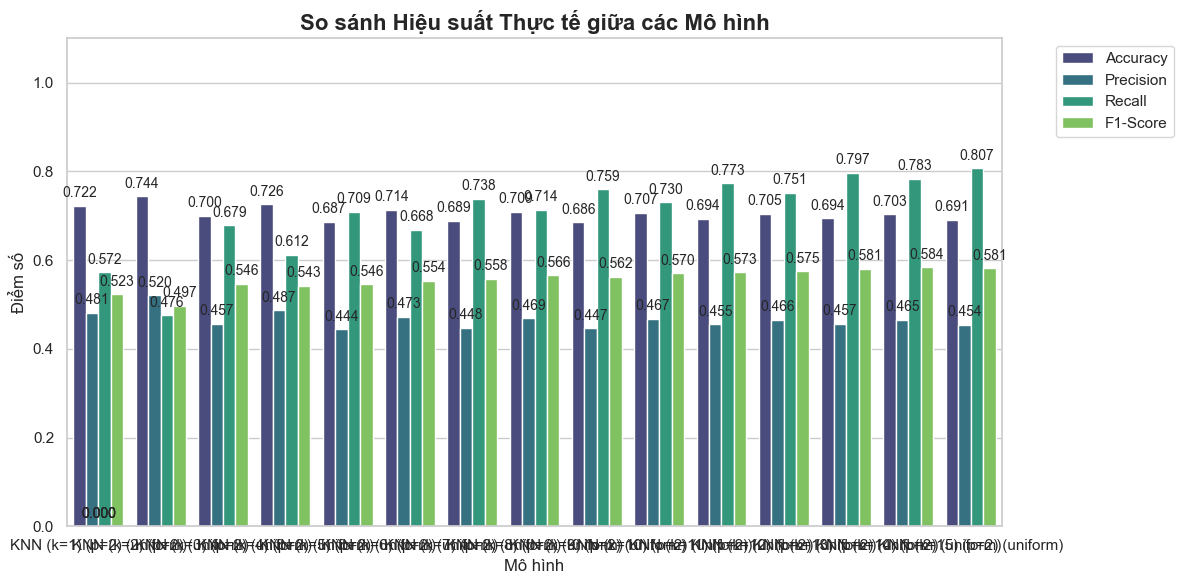

In [47]:
model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}
k_num = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
for k in k_num:
    knn_standard = CustomKNN(k=k)
    knn_standard.fit(X_train_resampled.values, y_train_resampled.values)
    y_pred_knn = knn_standard.predict(X_test.values)
    save_model_results(model_results, f'KNN (k={k}) (p=2) (uniform)', y_test.values, y_pred_knn)
create_comparison_table(model_results)

In [48]:
Knn_model_results = {
    'Mô hình': [model_results['Mô hình'][9]],
    'Accuracy': [model_results['Accuracy'][9]],
    'Precision': [model_results['Precision'][9]],
    'Recall': [model_results['Recall'][9]],
    'F1-Score': [model_results['F1-Score'][9]]
}

Đã lưu kết quả cho KNN (k=1) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=2) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=3) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=4) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=5) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=6) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=7) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=8) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=9) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=10) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=11) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=12) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=13) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=14) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=15) (p=1) (uniform)
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,KNN (k=1) (p=1) (uniform),0.7363,0.5036,0.5668,0.5333
1,KNN (k=2) (p=1) (uniform),0.7463,0.5277,0.4332,0.4758
2,KNN (k=3) (p=1) (uniform),0.7235,0.4847,0.6364,0.5503
3,KNN (k=4) (p=1) (uniform),0.7484,0.5244,0.5749,0.5485
4,KNN (k=5) (p=1) (uniform),0.7242,0.4866,0.6791,0.5670
5,KNN (k=6) (p=1) (uniform),0.7399,0.5087,0.6257,0.5612
6,KNN (k=7) (p=1) (uniform),0.7214,0.4836,0.7112,0.5758
7,KNN (k=8) (p=1) (uniform),0.7356,0.5020,0.6765,0.5763
8,KNN (k=9) (p=1) (uniform),0.7150,0.4765,0.7326,0.5774
9,KNN (k=10) (p=1) (uniform),0.7321,0.4972,0.7059,0.5834


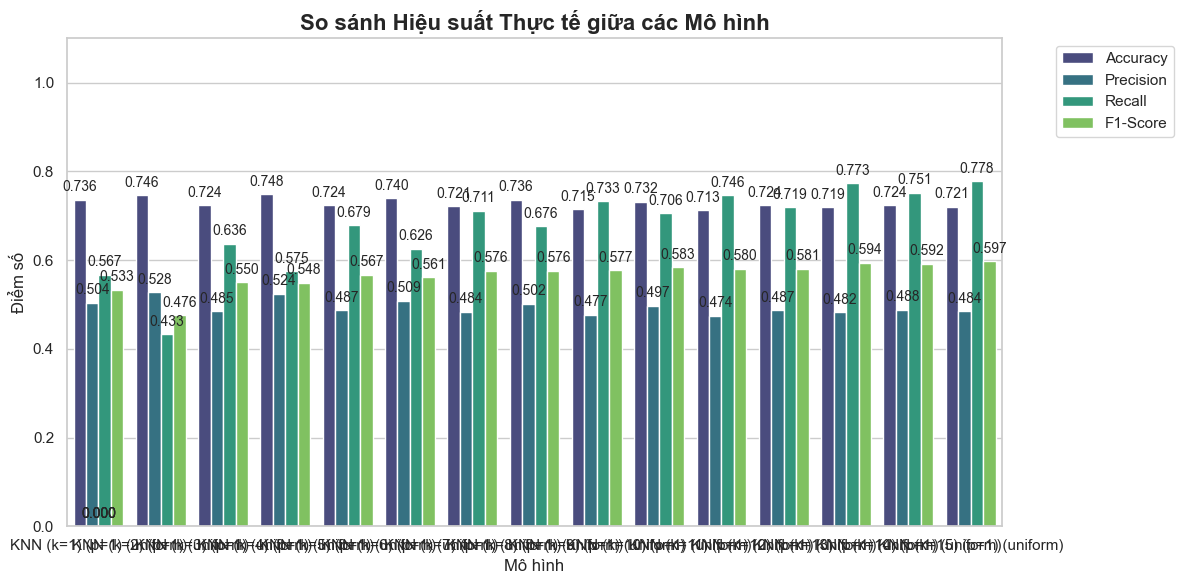

In [49]:
model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}
k_num = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
for k in k_num:
    knn_standard = CustomKNN(k=k, p=1)
    knn_standard.fit(X_train_resampled.values, y_train_resampled.values)
    y_pred_knn = knn_standard.predict(X_test.values)
    save_model_results(model_results, f'KNN (k={k}) (p=1) (uniform)', y_test.values, y_pred_knn)
create_comparison_table(model_results)

In [50]:
for key in model_results:
    Knn_model_results[key].append(model_results[key][14])

Đã lưu kết quả cho KNN (k=1) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=2) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=3) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=4) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=5) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=6) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=7) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=8) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=9) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=10) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=11) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=12) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=13) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=14) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=15) (p=mahalanobis) (uniform)
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,KNN (k=1) (p=mahalanobis) (uniform),0.7022,0.4530,0.5802,0.5088
1,KNN (k=2) (p=mahalanobis) (uniform),0.7214,0.4761,0.4786,0.4773
2,KNN (k=3) (p=mahalanobis) (uniform),0.6837,0.4397,0.6925,0.5379
3,KNN (k=4) (p=mahalanobis) (uniform),0.7015,0.4531,0.5936,0.5139
4,KNN (k=5) (p=mahalanobis) (uniform),0.6787,0.4377,0.7326,0.5480
5,KNN (k=6) (p=mahalanobis) (uniform),0.6944,0.4502,0.6765,0.5406
6,KNN (k=7) (p=mahalanobis) (uniform),0.6795,0.4407,0.7647,0.5591
7,KNN (k=8) (p=mahalanobis) (uniform),0.6958,0.4544,0.7193,0.5569
8,KNN (k=9) (p=mahalanobis) (uniform),0.6752,0.4374,0.7754,0.5593
9,KNN (k=10) (p=mahalanobis) (uniform),0.6994,0.4602,0.7567,0.5723


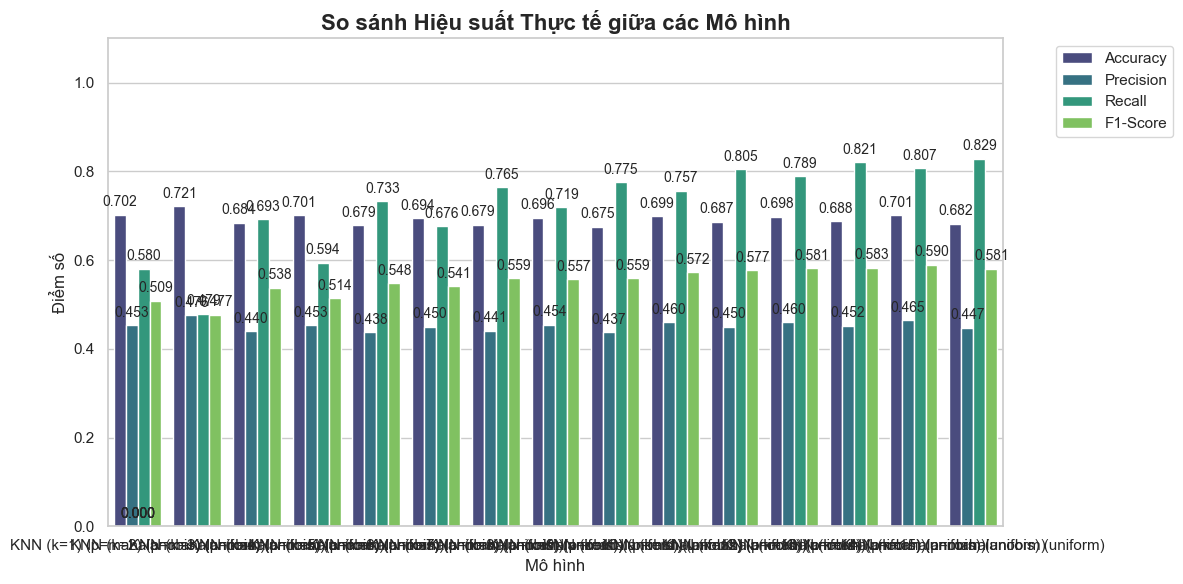

In [52]:
model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}
k_num = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
for k in k_num:
    knn_standard = CustomKNN(k=k, p='mahalanobis')
    knn_standard.fit(X_train_resampled.values, y_train_resampled.values)
    y_pred_knn = knn_standard.predict(X_test.values)
    save_model_results(model_results, f'KNN (k={k}) (p=mahalanobis) (uniform)', y_test.values, y_pred_knn)
create_comparison_table(model_results)

In [53]:
for key in model_results:
    Knn_model_results[key].append(model_results[key][13])

BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,KNN (k=10) (p=2) (uniform),0.7072,0.4675,0.7299,0.5699
1,KNN (k=15) (p=1) (uniform),0.7207,0.4842,0.7781,0.5969
2,KNN (k=14) (p=mahalanobis) (uniform),0.7015,0.4646,0.8075,0.5898


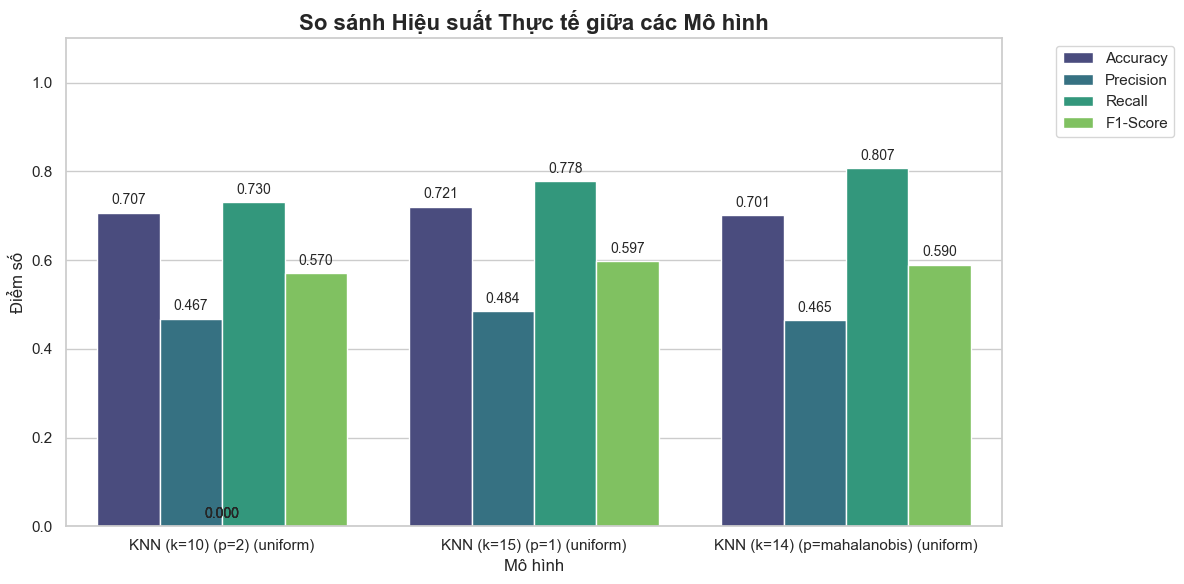

In [54]:
create_comparison_table(Knn_model_results)

Đã lưu kết quả cho KNN (k=1) (p=2) (distance)
Đã lưu kết quả cho KNN (k=2) (p=2) (distance)
Đã lưu kết quả cho KNN (k=3) (p=2) (distance)
Đã lưu kết quả cho KNN (k=4) (p=2) (distance)
Đã lưu kết quả cho KNN (k=5) (p=2) (distance)
Đã lưu kết quả cho KNN (k=6) (p=2) (distance)
Đã lưu kết quả cho KNN (k=7) (p=2) (distance)
Đã lưu kết quả cho KNN (k=8) (p=2) (distance)
Đã lưu kết quả cho KNN (k=9) (p=2) (distance)
Đã lưu kết quả cho KNN (k=10) (p=2) (distance)
Đã lưu kết quả cho KNN (k=11) (p=2) (distance)
Đã lưu kết quả cho KNN (k=12) (p=2) (distance)
Đã lưu kết quả cho KNN (k=13) (p=2) (distance)
Đã lưu kết quả cho KNN (k=14) (p=2) (distance)
Đã lưu kết quả cho KNN (k=15) (p=2) (distance)
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,KNN (k=1) (p=2) (distance),0.7221,0.4809,0.5722,0.5226
1,KNN (k=2) (p=2) (distance),0.7221,0.4808,0.5695,0.5214
2,KNN (k=3) (p=2) (distance),0.7065,0.4618,0.6310,0.5333
3,KNN (k=4) (p=2) (distance),0.7129,0.4698,0.6230,0.5356
4,KNN (k=5) (p=2) (distance),0.6965,0.4516,0.6604,0.5364
5,KNN (k=6) (p=2) (distance),0.7114,0.4700,0.6711,0.5529
6,KNN (k=7) (p=2) (distance),0.7022,0.4603,0.6979,0.5547
7,KNN (k=8) (p=2) (distance),0.7129,0.4727,0.6952,0.5628
8,KNN (k=9) (p=2) (distance),0.6951,0.4527,0.7032,0.5508
9,KNN (k=10) (p=2) (distance),0.7029,0.4609,0.6925,0.5534


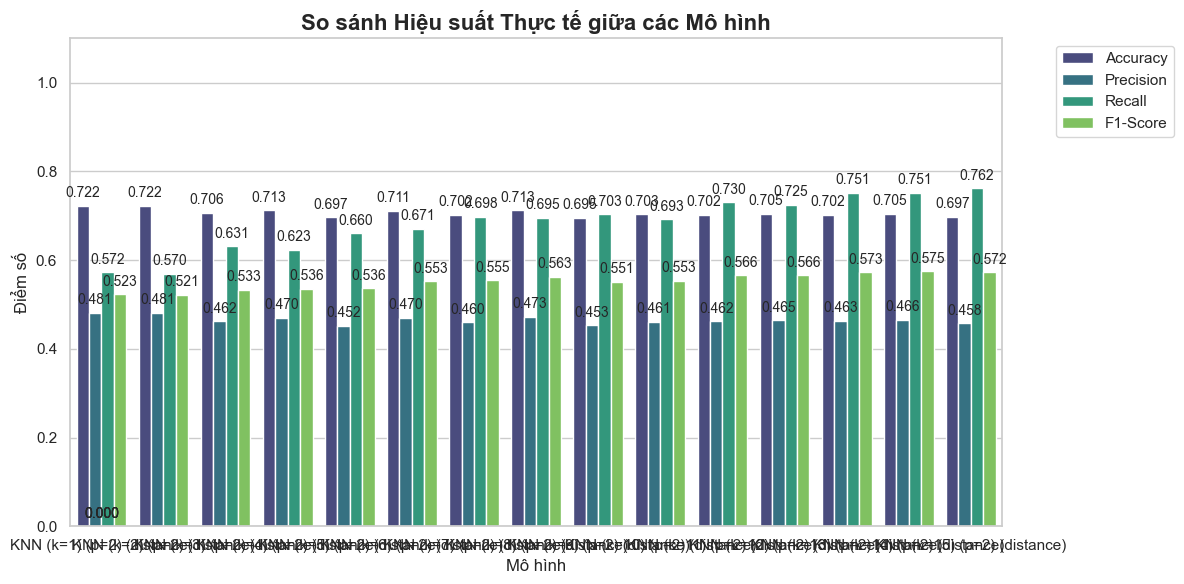

In [58]:
model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}
k_num = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
for k in k_num:
    knn_standard = CustomKNN(k=k, p=2, weights='distance')
    knn_standard.fit(X_train_resampled.values, y_train_resampled.values)
    y_pred_knn = knn_standard.predict(X_test.values)
    save_model_results(model_results, f'KNN (k={k}) (p=2) (distance)', y_test.values, y_pred_knn)
create_comparison_table(model_results)

In [59]:
for key in model_results:
    Knn_model_results[key].append(model_results[key][13])

Đã lưu kết quả cho KNN (k=1) (p=1) (distance)
Đã lưu kết quả cho KNN (k=2) (p=1) (distance)
Đã lưu kết quả cho KNN (k=3) (p=1) (distance)
Đã lưu kết quả cho KNN (k=4) (p=1) (distance)
Đã lưu kết quả cho KNN (k=5) (p=1) (distance)
Đã lưu kết quả cho KNN (k=6) (p=1) (distance)
Đã lưu kết quả cho KNN (k=7) (p=1) (distance)
Đã lưu kết quả cho KNN (k=8) (p=1) (distance)
Đã lưu kết quả cho KNN (k=9) (p=1) (distance)
Đã lưu kết quả cho KNN (k=10) (p=1) (distance)
Đã lưu kết quả cho KNN (k=11) (p=1) (distance)
Đã lưu kết quả cho KNN (k=12) (p=1) (distance)
Đã lưu kết quả cho KNN (k=13) (p=1) (distance)
Đã lưu kết quả cho KNN (k=14) (p=1) (distance)
Đã lưu kết quả cho KNN (k=15) (p=1) (distance)
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,KNN (k=1) (p=1) (distance),0.7363,0.5036,0.5668,0.5333
1,KNN (k=2) (p=1) (distance),0.7363,0.5036,0.5615,0.5310
2,KNN (k=3) (p=1) (distance),0.7285,0.4912,0.5963,0.5386
3,KNN (k=4) (p=1) (distance),0.7370,0.5045,0.6016,0.5488
4,KNN (k=5) (p=1) (distance),0.7306,0.4948,0.6337,0.5557
5,KNN (k=6) (p=1) (distance),0.7420,0.5115,0.6551,0.5744
6,KNN (k=7) (p=1) (distance),0.7321,0.4970,0.6711,0.5711
7,KNN (k=8) (p=1) (distance),0.7342,0.5000,0.6738,0.5740
8,KNN (k=9) (p=1) (distance),0.7235,0.4857,0.6791,0.5663
9,KNN (k=10) (p=1) (distance),0.7306,0.4952,0.6872,0.5756


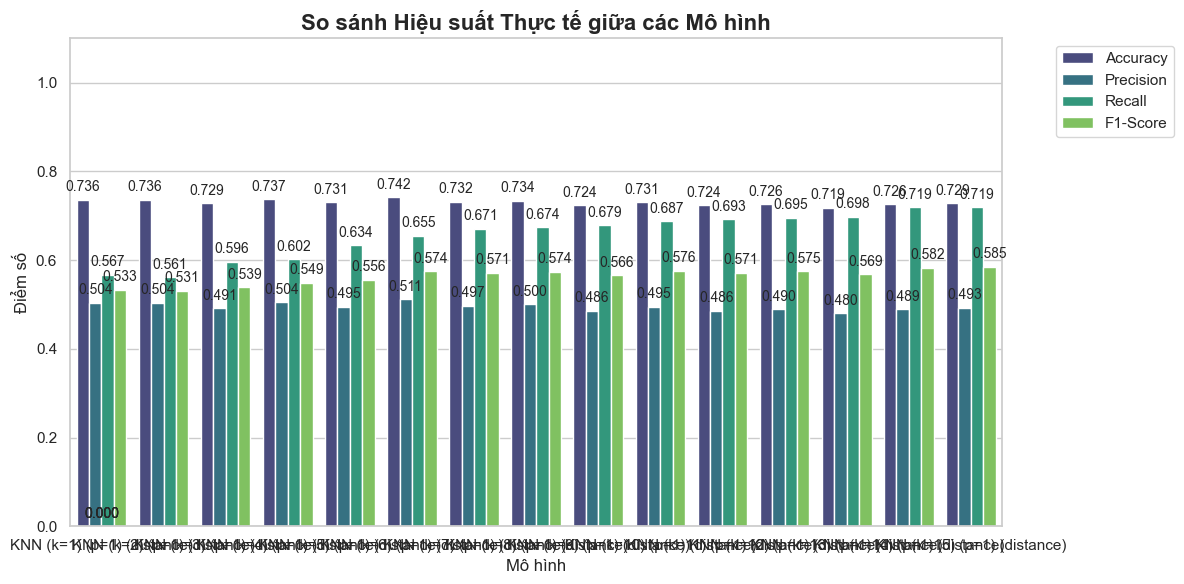

In [60]:
model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}
k_num = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
for k in k_num:
    knn_standard = CustomKNN(k=k, p=1, weights='distance')
    knn_standard.fit(X_train_resampled.values, y_train_resampled.values)
    y_pred_knn = knn_standard.predict(X_test.values)
    save_model_results(model_results, f'KNN (k={k}) (p=1) (distance)', y_test.values, y_pred_knn)
create_comparison_table(model_results)

In [61]:
for key in model_results:
    Knn_model_results[key].append(model_results[key][13])

Đã lưu kết quả cho KNN (k=1) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=2) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=3) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=4) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=5) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=6) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=7) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=8) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=9) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=10) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=11) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=12) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=13) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=14) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=15) (p=mahalanobis) (distance)
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,KNN (k=1) (p=mahalanobis) (distance),0.7022,0.4530,0.5802,0.5088
1,KNN (k=2) (p=mahalanobis) (distance),0.7043,0.4559,0.5802,0.5106
2,KNN (k=3) (p=mahalanobis) (distance),0.6844,0.4388,0.6711,0.5307
3,KNN (k=4) (p=mahalanobis) (distance),0.6923,0.4463,0.6551,0.5309
4,KNN (k=5) (p=mahalanobis) (distance),0.6830,0.4390,0.6925,0.5373
5,KNN (k=6) (p=mahalanobis) (distance),0.6859,0.4426,0.7005,0.5424
6,KNN (k=7) (p=mahalanobis) (distance),0.6816,0.4397,0.7219,0.5466
7,KNN (k=8) (p=mahalanobis) (distance),0.6830,0.4414,0.7246,0.5486
8,KNN (k=9) (p=mahalanobis) (distance),0.6851,0.4452,0.7487,0.5583
9,KNN (k=10) (p=mahalanobis) (distance),0.6880,0.4482,0.7513,0.5614


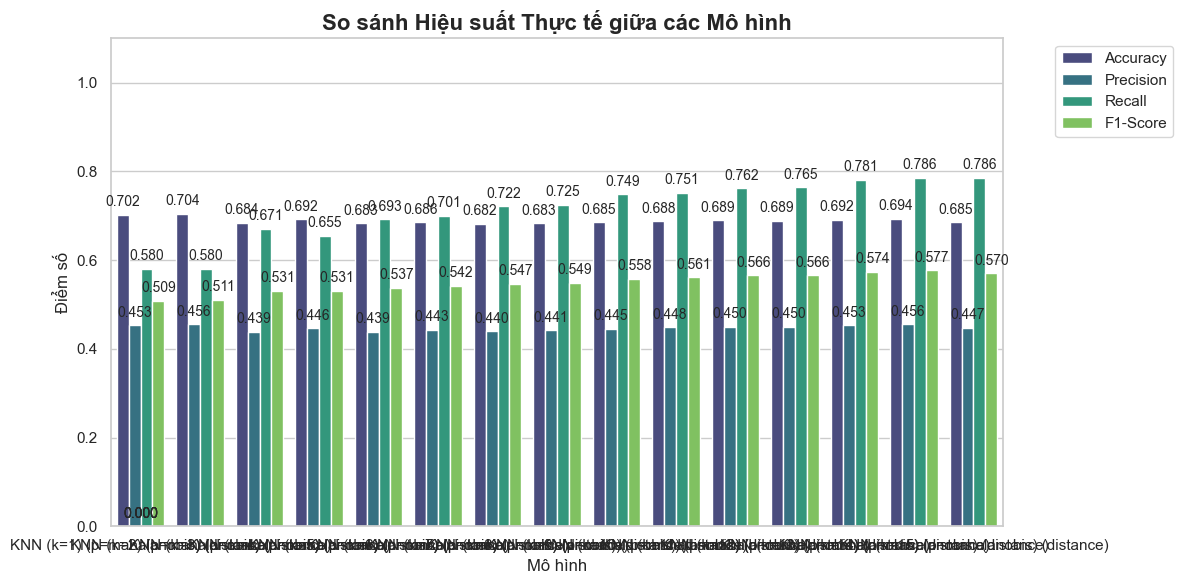

In [62]:
model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}
k_num = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
for k in k_num:
    knn_standard = CustomKNN(k=k, p='mahalanobis', weights='distance')
    knn_standard.fit(X_train_resampled.values, y_train_resampled.values)
    y_pred_knn = knn_standard.predict(X_test.values)
    save_model_results(model_results, f'KNN (k={k}) (p=mahalanobis) (distance)', y_test.values, y_pred_knn)
create_comparison_table(model_results)

In [63]:
for key in model_results:
    Knn_model_results[key].append(model_results[key][12])

BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,KNN (k=10) (p=2) (uniform),0.7072,0.4675,0.7299,0.5699
1,KNN (k=15) (p=1) (uniform),0.7207,0.4842,0.7781,0.5969
2,KNN (k=14) (p=mahalanobis) (uniform),0.7015,0.4646,0.8075,0.5898
3,KNN (k=14) (p=2) (distance),0.7050,0.4660,0.7513,0.5752
4,KNN (k=14) (p=1) (distance),0.7257,0.4891,0.7193,0.5823
5,KNN (k=13) (p=mahalanobis) (distance),0.6915,0.4534,0.7807,0.5737


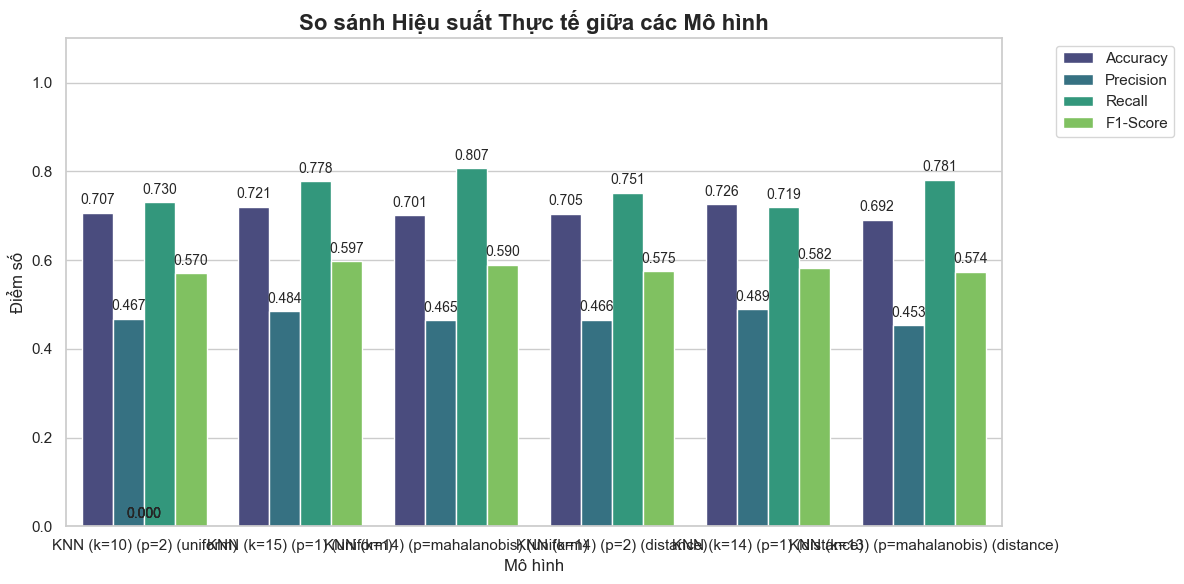

In [64]:
create_comparison_table(Knn_model_results)